In [188]:
import refinitiv.data as rd
import pandas as pd
from datetime import date, timedelta, datetime
import numpy as np
import matplotlib.pyplot as plt
import numpy_financial as npf
from scipy.optimize import brentq
import math

In [103]:
key7 = 'afa544907ced4690b75ab2e31be66bc5af09caa9'
key8 = '774f340989704932aa5c85967cfacd8c1c06642d'
key = key8
rd.open_session(app_key=key)

<refinitiv.data.session.Definition object at 0x28605571250 {name='workspace'}>

# YTM Functions

In [189]:
def gen_date_range(start_date, end_date, step_days):
    date_range = pd.date_range(
        start=start_date,
        end=end_date,
        freq=pd.DateOffset(days=step_days)
    )
    return date_range

def calc_xirr(cash_flows, dates, year_convention=360.0):
    '''
    cash_flows must be a list of the cash amounts in date order (negative for outflow)
    dates must be a list of timestamps that represent the inflow or outflow of the cash_flows list, it must be the same length
    '''

    dates = pd.to_datetime(dates)
    t0 = dates[0] #investment date

    # convert each date into a year fraction from t0
    times = [(d - t0).days / year_convention for d in dates]

    # define the npv function
    # this computes present value of all cash flows
    # discounted at the given rate
    def npv(rate):
        return sum(cf / (1 + rate)**t for cf, t in zip(cash_flows, times))
    
    # solve for the rate that makes npv = 0
    # search between -99% and 500% annual yield
    return brentq(npv, -0.99, 5.0)

def calc_clean_price(price, coupon, coupon_days_freq, issue_date, maturity_date, face_v=100):
    today = pd.Timestamp.today().normalize()
    coupon_money = (face_v * coupon/100) * (coupon_days_freq/360)

    coupon_dates = gen_date_range(issue_date, maturity_date, coupon_days_freq)
    previous_coupon_date = coupon_dates[coupon_dates <= today].max()

    # the price from refinitiv is already the dirty price
    days_since_last_c = (today - previous_coupon_date).days
    acc_int = coupon_money * (days_since_last_c / coupon_days_freq)
    clean_price = price - acc_int
    
    return clean_price

def calc_ytm(price, coupon, coupon_days_freq, issue_date, maturity_date, face_v=100):
    today = pd.Timestamp.today().normalize()

    coupon_money = (face_v * coupon/100) * (coupon_days_freq/360)

    coupon_dates = gen_date_range(issue_date, maturity_date, coupon_days_freq) # generate the coupon payment dates

    if today in coupon_dates:
        cash_flow_dates = []
        cash_flows = [-price]

        for date in coupon_dates[coupon_dates > today]:
            cash_flow_dates.append(date)
            cash_flows.append(coupon_money)
        
        cash_flows[-1] = cash_flows[-1] + face_v # adding principal
        ytm = npf.irr(cash_flows) 
        return ytm * (360 / coupon_days_freq), cash_flows, cash_flow_dates

    else:
        '''
        # the price from refinitiv is already the dirty price
        # dirty price
        days_since_last_c = (today - previous_coupon_date).days
        acc_int = coupon_money * (days_since_last_c / coupon_days_freq)
        dirty_price = price + acc_int
        '''
        cash_flow_dates = [today]
        cash_flows = [-price]
        
        for date in coupon_dates[coupon_dates > today]:
            cash_flow_dates.append(date)
            cash_flows.append(coupon_money)
        
        cash_flows[-1] = cash_flows[-1] + face_v # adding principal
        
        ytm = calc_xirr(cash_flows, cash_flow_dates)
        return ytm, cash_flows, cash_flow_dates

In [58]:
#Using a Refinitiv SCREEN() expression to retrieve the universe of active tickers in the mx
screener = (
    'SCREEN('
      'U(IN(Equity(active,public,primary))/*UNV:Public*/), '
      # country
      'TR.ExchangeCountryCode = "MX"'
    ')'
)

# the data i want to gather (will be useful to do further screening)
fields = [
    'TR.CommonName',
    'TR.ISIN',
    'TR.CompanyMarketCap(Scale=0)',
    'TR.ExchangeName',
    'TR.TRBCEconomicSector',
    'TR.TRBCIndustryGroup',
    'TR.AssetCategory',
    'TR.FirstTradeDate'
]

screener_mx = rd.get_data(screener, fields)
screener_mx

C:\Users\Ramon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


,Instrument,Company Common Name,ISIN,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date
0,MINSAB.MX,Grupo Minsa SAB de CV,MXP510501119,3471994159.8,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Tobacco,Ordinary Share,1997-05-16
1,GMD.MX,Grupo Mexicano de Desarrollo SAB,MX01GM080002,1277352944.0,Bolsa Mexicana de Valores S.A. de C.V.,Industrials,Construction & Engineering,Ordinary Share,1993-12-20
2,VALUEGFO.MX,Value Grupo Financiero SAB de CV,MXP800761019,10878400000.0,Bolsa Mexicana de Valores S.A. de C.V.,Financials,Investment Banking & Investment Services,Ordinary Share,1992-12-11
3,EDOARDOB.MX,Edoardos Martin SAB de CV,MXP310341013,48553101.6,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Cyclicals,Textiles & Apparel,Ordinary Share,1990-03-19
4,QBINDUSA.MX,QB Industrias SA de CV,MXP793911019,1468267483.2,Bolsa Mexicana de Valores S.A. de C.V.,Basic Materials,Chemicals,Ordinary Share,1992-07-15
...,...,...,...,...,...,...,...,...,...
145,GLOBCA.MX,Tenedora de Acciones CM SA de CV,MX1SGL050004,6534313870.2,Bolsa Mexicana de Valores S.A. de C.V.,Financials,Banking Services,Ordinary Share,2024-02-28
146,DIABLOSA.MX,Diablos Rojos del Mexico SAPIB de CV,MX1SDI2B0004,2047885520.0,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Cyclicals,Hotels & Entertainment Services,Ordinary Share,NaT
147,NEXT25.MX,Fideicomiso Irrevocable No 7401,MXCFNE040015,38687069149.379997,Bolsa Mexicana de Valores S.A. de C.V.,Real Estate,Residential & Commercial REITs,Ordinary Share,2025-07-24
148,NUTRISAA.MX,Nutrisa SA de CV,MX01NU070004,1382949513.8,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Tobacco,Ordinary Share,2025-09-18


In [59]:
screener_mx['Asset Category Description'].value_counts()

Asset Category Description
Ordinary Share                                131
Mexican Ordinary Participation Certificate      8
Equity ETF                                      7
Bond ETF                                        2
Unit                                            2
Name: count, dtype: Int64

In [60]:
filtered_screener_mx = screener_mx[screener_mx['Asset Category Description'].isin(['Ordinary Share', 'Mexican Ordinary Participation Certificate'])]
filtered_screener_mx

,Instrument,Company Common Name,ISIN,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date
0,MINSAB.MX,Grupo Minsa SAB de CV,MXP510501119,3471994159.8,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Tobacco,Ordinary Share,1997-05-16
1,GMD.MX,Grupo Mexicano de Desarrollo SAB,MX01GM080002,1277352944.0,Bolsa Mexicana de Valores S.A. de C.V.,Industrials,Construction & Engineering,Ordinary Share,1993-12-20
2,VALUEGFO.MX,Value Grupo Financiero SAB de CV,MXP800761019,10878400000.0,Bolsa Mexicana de Valores S.A. de C.V.,Financials,Investment Banking & Investment Services,Ordinary Share,1992-12-11
3,EDOARDOB.MX,Edoardos Martin SAB de CV,MXP310341013,48553101.6,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Cyclicals,Textiles & Apparel,Ordinary Share,1990-03-19
4,QBINDUSA.MX,QB Industrias SA de CV,MXP793911019,1468267483.2,Bolsa Mexicana de Valores S.A. de C.V.,Basic Materials,Chemicals,Ordinary Share,1992-07-15
...,...,...,...,...,...,...,...,...,...
145,GLOBCA.MX,Tenedora de Acciones CM SA de CV,MX1SGL050004,6534313870.2,Bolsa Mexicana de Valores S.A. de C.V.,Financials,Banking Services,Ordinary Share,2024-02-28
146,DIABLOSA.MX,Diablos Rojos del Mexico SAPIB de CV,MX1SDI2B0004,2047885520.0,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Cyclicals,Hotels & Entertainment Services,Ordinary Share,NaT
147,NEXT25.MX,Fideicomiso Irrevocable No 7401,MXCFNE040015,38687069149.379997,Bolsa Mexicana de Valores S.A. de C.V.,Real Estate,Residential & Commercial REITs,Ordinary Share,2025-07-24
148,NUTRISAA.MX,Nutrisa SA de CV,MX01NU070004,1382949513.8,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Tobacco,Ordinary Share,2025-09-18


In [61]:
ticker_names = list(filtered_screener_mx['Instrument'])
ticker_names

['MINSAB.MX',
 'GMD.MX',
 'VALUEGFO.MX',
 'EDOARDOB.MX',
 'QBINDUSA.MX',
 'TEKCHEMA.MX',
 'COLLADO.MX',
 'IASASA.MX',
 'ACCELSAB.MX',
 'CIDMEGA.MX',
 'DINEB.MX',
 'CHDRAUIB.MX',
 'ACTINVRB.MX',
 'TEAKCPO.MX',
 'CONVERA.MX',
 'SPORTS.MX',
 'GENTERA.MX',
 'MFRISCOA1.MX',
 'RA.MX',
 'ALPEKA.MX',
 'VESTA.MX',
 'Q.MX',
 'PV.MX',
 'CREAL.MX',
 'FIHO12.MX',
 'HCITY.MX',
 'VOLARA.MX',
 'HOTEL.MX',
 'AGUA.MX',
 'UNIFINA.MX',
 'GICSAB.MX',
 'NEMAKA.MX',
 'RLHA.MX',
 'CADUA.MX',
 'LACOMERUBC.MX',
 'PLANI.MX',
 'VINTE.MX',
 'FVIA16.MX',
 'FPLUS16.MX',
 'CUERVO.MX',
 'BBAJIOO.MX',
 'VISTAA.MX',
 'TRAXIONA.MX',
 'INFRAEX18.MX',
 'FCFE182.MX',
 'BAFARB.BIV',
 'LASITE.MX',
 'XFRA22.MX',
 'SITES1A1.MX',
 'FEXI21.MX',
 'FORION20.MX',
 'GAVA.MX',
 'COXA.MX',
 'FIDEAL20.MX',
 'AGRIEXPA.MX',
 'ALSEA.MX',
 'ARISTOSA.MX',
 'ARA.MX',
 'AC.MX',
 'AUTLANB.MX',
 'AHMSA.MX',
 'SIGMAFA.MX',
 'ASURB.MX',
 'AXTELCPO.MX',
 'CYDSASAA.MX',
 'FINAMEXO.MX',
 'BIMBOA.MX',
 'GCARSOA1.MX',
 'GFMULTIO.MX',
 'CMOCTEZ.MX',
 'B

# Getting subsidiares

Some companies in Mexico use subsidiaries to issue bonds.

In [ ]:
data = rd.get_data(
    universe=['AC.MX'],
    fields=['TR.RelatedOrgId', 'TR.RelatedOrgName', 'TR.RelatedOrgType'])

data

,Instrument,Related OrgId,Related Org Name,Related Org Type
0,AC.MX,5000434704,Petstar SA de CV,Affiliate
1,AC.MX,4295884351,Arca Continental SAB de CV,Subsidiary
2,AC.MX,5036860809,Holding Tonicorp SA,Subsidiary
3,AC.MX,4295990648,Embotelladora Aguascalientes SA de CV,Subsidiary
4,AC.MX,4295990662,Embotelladora Zacatecas SA de CV,Subsidiary
...,...,...,...,...
65,AC.MX,5071083909,Vending del Ecuador SA,Subsidiary
66,AC.MX,5071084031,Servicios Ejecutivos Arca Continental SA de CV,Subsidiary
67,AC.MX,5071084034,AC Bebidas Ecuador S de R L de CV,Subsidiary
68,AC.MX,5083871926,Productora Y Comercializadora De Bebidas Arca ...,Subsidiary


In [64]:
subsidiaries_by_ticker = {}
no_subsidiares_ticker = []

for ticker in ticker_names:
    data = rd.get_data(
        universe=[ticker],
        fields=['TR.RelatedOrgId', 'TR.RelatedOrgName', 'TR.RelatedOrgType']
    )

    if data.empty:
        no_subsidiares_ticker.append(ticker)
    else:
        subsidiaries_by_ticker[ticker] = list(data['Related Org Name'])

C:\Users\Ramon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [ ]:
# some tickers have blank spaces in the column 'Related Org Name' for the subsidiaries, i should drop that before doing anything

In [65]:
no_subsidiares_ticker

[]

In [74]:
subsidiaries_by_ticker['VALUEGFO.MX']

['Value Grupo Financiero SAB de CV',
 'Value SA de CV Casa de Bolsa Value Grupo Financiero',
 'Value Arrendadora SA de CV SOFOM ER Value Grupo Financiero',
 'Value Consultores SA de CV',
 'Value Factoraje Organizacion Auxiliar Del Credito Value Grupo Fina SA de CV']

In [72]:
company_names = list(filtered_screener_mx['Company Common Name']) 
company_and_subsidiaries_names = [s for lst in subsidiaries_by_ticker.values() for s in lst] + company_names

In [73]:
len(company_and_subsidiaries_names)

2554

In [31]:
comp_name = company_names[0]
comp_name

'Grupo Minsa SAB de CV'

In [75]:
bonds_data_df = rd.discovery.search(
    view = rd.discovery.Views.FIXED_INCOME_INSTRUMENTS,
    filter = f"IssuerCommonName eq 'Value Arrendadora SA de CV SOFOM ER Value Grupo Financiero'",
    top = 1000,
    select='RIC,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency'
)

today = pd.Timestamp.today().normalize()
bonds_data_df = bonds_data_df[bonds_data_df['MaturityDate'] > today]

In [76]:
bonds_data_df

,RIC,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency
0,MX91VA2600J3=VALR,MX91VA2600J3,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-04-16,2029-04-10,9.68,1000000000,MXN
1,MX91VA2600K1=VALR,MX91VA2600K1,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-06-20,2029-06-14,9.75,500000000,MXN
2,MX91VA2600L9=VALR,MX91VA2600L9,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-10-15,2029-10-09,9.75,500000000,MXN
3,MX91VA2600M7=VALR,MX91VA2600M7,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2025-07-24,2030-07-18,8.65,1000000000,MXN


In [ ]:
company_names_upper = [c.upper() for c in company_names]
company_names_upper

In [89]:
from tqdm import tqdm

In [91]:
from tqdm import tqdm # to see progress

dfs = []
comp_bond_data = []
comp_no_bond_data = []
error_company = {}

for company in tqdm(company_and_subsidiaries_names): #mininterval= can help reduce overhead. default is .1 s
    try:
        company_bonds_data_df = rd.discovery.search(
            view = rd.discovery.Views.FIXED_INCOME_INSTRUMENTS,
            filter = f"IssuerCommonName eq '{company}'",
            top = 1000,
            select='RIC,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency')
    
        if company_bonds_data_df.empty:
            comp_no_bond_data.append(company)
            continue

        else:
            comp_bond_data.append(company)
            dfs.append(company_bonds_data_df)

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        error_company[company] = e

# concatenate all dfs
final_bonds_df = pd.concat(dfs, ignore_index=True)

 25%|██▌       | 642/2554 [05:21<15:06,  2.11it/s]

Error with ESENTIAI.MX: Error code 503 | <html>
<head><title>503 Service Temporarily Unavailable</title></head>
<body>
<center><h1>503 Service Temporarily Unavailable</h1></center>
</body>
</html>
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->



 33%|███▎      | 837/2554 [06:57<13:53,  2.06it/s]

Error with ESENTIAI.MX: Error code 400 | Invalid filter: unexpected <s> immediately after string <'Emmy'> (hint: escape literal <'> as <''>)


 34%|███▍      | 880/2554 [07:18<13:48,  2.02it/s]

...

 95%|█████████▍| 2414/2554 [20:16<01:11,  1.96it/s]

Error with ESENTIAI.MX: Error code 400 | Invalid filter: empty strings have no meaning; to express 'no value', use null


 95%|█████████▍| 2415/2554 [20:17<01:12,  1.92it/s]

Error with ESENTIAI.MX: Error code 400 | Invalid filter: empty strings have no meaning; to express 'no value', use null


100%|██████████| 2554/2554 [21:28<00:00,  1.98it/s]


In [ ]:
# the other thing i can do is to gather all the bond data and once i have the full df then i filter by maturitydate to have only the active bonds

In [92]:
final_bonds_df

,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency,RIC
0,US40048GAA22,Grupo Mexicano de Desarrollo SAB,"Grupo Mexicano de Desarrollo SAB, Plain Vanill...",1994-02-17,2001-02-17,8.25,250000000.0,USD,<NA>
1,USP49536AA68,Grupo Mexicano de Desarrollo SAB,"Grupo Mexicano de Desarrollo SAB, Plain Vanill...",1994-02-17,2001-02-17,8.25,250000000.0,USD,<NA>
2,MX91DH000027,Desarrollos Hidraulicos de Cancun SA de CV,"Desarrollos Hidraulicos de Cancun SA de CV, Fi...",2022-11-18,2026-05-29,11.02,1400000000.0,MXN,MX91DH000027=VALR
3,MX91DH000019,Desarrollos Hidraulicos de Cancun SA de CV,"Desarrollos Hidraulicos de Cancun SA de CV, Fi...",2015-12-04,2022-11-25,11.14,1650000000.0,MXN,<NA>
4,MX91DH000001,Desarrollos Hidraulicos de Cancun SA de CV,"Desarrollos Hidraulicos de Cancun SA de CV, Fi...",2014-12-17,2019-12-11,5.03,900000000.0,MXN,<NA>
...,...,...,...,...,...,...,...,...,...
20896,MX93AM050521,America Movil SAB de CV,"America Movil SAB de CV, Commercial Paper, AMX...",2025-04-03,2025-06-26,0.0,300311500.0,MXN,<NA>
20897,MX93AM0502R1,America Movil SAB de CV,"America Movil SAB de CV, Commercial Paper, AMX...",2024-07-18,2024-09-12,0.0,1444400.0,MXN,<NA>
20898,MX93AM050497,America Movil SAB de CV,"America Movil SAB de CV, Commercial Paper, AMX...",2024-12-05,2025-01-16,0.0,162693600.0,MXN,<NA>
20899,MX93AM050190,America Movil SAB de CV,"America Movil SAB de CV, Commercial Paper, AMX...",2024-04-11,2024-06-06,0.0,40017900.0,MXN,<NA>


In [93]:
error_company

{'Servicios Quimobasicos SA de CV': refinitiv.data._errors.RDError(503,
                                '<html>\r\n<head><title>503 Service Temporarily Unavailable</title></head>\r\n<body>\r\n<center><h1>503 Service Temporarily Unavailable</h1></center>\r\n</body>\r\n</html>\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n'),
 "Emmy's Organics LLC": refinitiv.data._errors.RDError(400,
                                "Invalid filter: unexpected <s> immediately after string <'Emmy'> (hint: escape literal <'> as <''>)"),
 '': refinitiv.data._errors.RDError(400,
                                "Invalid filter: empty strings hav

In [94]:
final_bonds_df.dtypes

ISIN                string[python]
IssuerCommonName    string[python]
DocumentTitle       string[python]
IssueDate           datetime64[ns]
MaturityDate        datetime64[ns]
CouponRate                 Float64
FaceIssuedTotal            Float64
Currency            string[python]
RIC                 string[python]
dtype: object

In [100]:
today = pd.Timestamp.today().normalize()
final_bonds_df = final_bonds_df[final_bonds_df['MaturityDate'] > today]
final_bonds_df = final_bonds_df[final_bonds_df['Currency'] == 'MXN']
final_bonds_df

,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency,RIC
2,MX91DH000027,Desarrollos Hidraulicos de Cancun SA de CV,"Desarrollos Hidraulicos de Cancun SA de CV, Fi...",2022-11-18,2026-05-29,11.02,1400000000.0,MXN,MX91DH000027=VALR
5,MX91VA2600J3,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-04-16,2029-04-10,9.68,1000000000.0,MXN,MX91VA2600J3=VALR
6,MX91VA2600K1,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-06-20,2029-06-14,9.75,500000000.0,MXN,MX91VA2600K1=VALR
7,MX91VA2600L9,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-10-15,2029-10-09,9.75,500000000.0,MXN,MX91VA2600L9=VALR
8,MX91VA2600M7,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2025-07-24,2030-07-18,8.65,1000000000.0,MXN,MX91VA2600M7=VALR
...,...,...,...,...,...,...,...,...,...
20524,XS2701559440,America Movil SAB de CV,"America Movil SAB de CV, Plain Vanilla Fixed C...",2024-02-01,2034-01-30,10.3,23500000000.0,MXN,MX270155944=
20527,XS0278859771,America Movil SAB de CV,"America Movil SAB de CV, Plain Vanilla Fixed C...",2006-12-18,2036-12-18,8.46,8000000000.0,MXN,MX027885977=
20528,XS0278906440,America Movil SAB de CV,"America Movil SAB de CV, Plain Vanilla Fixed C...",2006-12-18,2036-12-18,8.46,8000000000.0,MXN,02365HAA5=
20529,XS0329579600,America Movil SAB de CV,"America Movil SAB de CV, Plain Vanilla Fixed C...",2007-11-21,2036-12-18,8.46,7355500000.0,MXN,MX032957960=


In [110]:
final_bonds_df.isna().sum()

ISIN                22
IssuerCommonName     0
DocumentTitle        0
IssueDate            0
MaturityDate         0
CouponRate           0
FaceIssuedTotal      0
Currency             0
RIC                  9
dtype: int64

In [111]:
final_bonds_df = final_bonds_df.dropna(subset=['ISIN'])
final_bonds_df.isna().sum()

ISIN                0
IssuerCommonName    0
DocumentTitle       0
IssueDate           0
MaturityDate        0
CouponRate          0
FaceIssuedTotal     0
Currency            0
RIC                 1
dtype: int64

In [112]:
isin_bonds = list(final_bonds_df['ISIN'])

In [ ]:
isin = 'MX91GM1Z0028'

bond_data = rd.get_data(
    universe=[isin],
    fields = ['TR.IssuerRating', 'TR.IR.RatingSourceDescription'])

bond_data

,Instrument,Issuer Rating,Issuer Name,Rating Source Description
0,MX91GM1Z0028,AAA(mex),GMEXICO TRANSPORTES SAB DE CV,Fitch Long-term Issuer National Scale Rating


In [ ]:
isin = 'MX91GM1Z0028'

bond_data = rd.get_data(
    universe=[isin],
    fields=[
        'TR.FiIssuerName',
        'TR.UltimateParent',
        'TR.TRBCEconomicSector',
        'TR.TRBCBusinessSector',
        'TR.TRBCIndustryGroup',
        'TR.FIPrice',
        "TR.RIC",
        'TR.CA.AmtOutstanding',
        "TR.CouponRate",
        'TR.FiCouponType',
        'TR.InterestFormula',
        'TR.FRNFORMULA',
        'TR.FiCouponFrequency',
        'TR.FiCouponFrequencyDescription',
        "TR.FiCurrency",
        'TR.FiIssueDate',
        'TR.FiMaturityDate',
        'TR.FiIssuerSPLongRating',
        'TR.FiIssuerFitchLongRating',
        'TR.FiIssuerMoodysLongRating',
        'TR.FiLiquidationRank',
        'TR.FiSeniorityType',
        'TR.FiSeniorityTypeDescription',
        'TR.FiMaturityStandardYield',
        'TR.FiIsCallable',
        'TR.FiIsStraight',
        'TR.FiESGBondFlag',
        'TR.FiESGBondType',
        'TR.TRESGScoreGrade'])

bond_data

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Issuer Moodys Long Rating,Liquidation Rank,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade
0,MX91AC100049,ARCA CONTINENTAL SAB DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100.13,MX91AC100049=VALR,3200000000,7.3,...,A3,Senior Unsecured,UN,Unsecured,7.356421,Y,N,N,,B


In [168]:
bond_data['Issuer Moodys Long Rating']

0    A3
Name: Issuer Moodys Long Rating, dtype: string

In [261]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

dfs = []
error_isins = []

for isin in tqdm(isin_bonds, mininterval=1):
    try:
        bond_data = rd.get_data(
            universe=[isin],
            fields=[
                'TR.FiIssuerName',
                'TR.UltimateParent',
                'TR.TRBCEconomicSector',
                'TR.TRBCBusinessSector',
                'TR.TRBCIndustryGroup',
                'TR.FIPrice',
                "TR.RIC",
                'TR.CA.AmtOutstanding',
                "TR.CouponRate",
                'TR.FiCouponType',
                'TR.InterestFormula',
                'TR.FRNFORMULA',
                'TR.FiCouponFrequency',
                'TR.FiCouponFrequencyDescription',
                "TR.FiCurrency",
                'TR.FiIssueDate',
                'TR.FiMaturityDate',
                'TR.IssuerRating', 
                'TR.IR.RatingSourceDescription',
                'TR.FiIssuerFitchLongRating',
                'TR.FiIssuerMoodysLongRating',
                'TR.FiLiquidationRank',
                'TR.FiSeniorityType',
                'TR.FiSeniorityTypeDescription',
                'TR.FiMaturityStandardYield',
                'TR.FiIsCallable',
                'TR.FiIsStraight',
                'TR.FiESGBondFlag',
                'TR.FiESGBondType',
                'TR.TRESGScoreGrade'])

        dfs.append(bond_data)

    except Exception as e:
        error_isins.append(isin)
        print(f'Error with {isin}: {e}')

final_bonds_data_df = pd.concat(dfs, ignore_index=True)

100%|██████████| 525/525 [19:59<00:00,  2.28s/it] 


In [265]:
final_bonds_data_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Issuer Moodys Long Rating,Liquidation Rank,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade
0,MX91DH000027,DESARROLLOS HIDRAULICOS DE CANCUN SA DE CV,Grupo Mexicano de Desarrollo SAB,Utilities,Utilities,Water & Related Utilities,NaN,MX91DH000027=VALR,1355555558.0,11.02,...,<NA>,Senior Unsecured,UN,Unsecured,NaN,Y,N,Y,Sustainability Bond,<NA>
1,MX91VA2600J3,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600J3=VALR,1000000000.0,9.68,...,<NA>,Senior Unsecured,UN,Unsecured,NaN,N,N,N,<NA>,<NA>
2,MX91VA2600K1,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600K1=VALR,500000000.0,9.75,...,<NA>,Senior Unsecured,UN,Unsecured,NaN,N,N,N,<NA>,<NA>
3,MX91VA2600L9,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600L9=VALR,500000000.0,9.75,...,<NA>,Senior Unsecured,UN,Unsecured,NaN,N,N,N,<NA>,<NA>
4,MX91VA2600M7,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600M7=VALR,1000000000.0,8.65,...,<NA>,Senior Unsecured,UN,Unsecured,NaN,Y,N,N,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,MX91AM0500P3,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100.0100,MX91AM0500P3=VALR,14679165700.0,9.52,...,WR,Senior Unsecured,UN,Unsecured,9.512164,Y,N,Y,Sustainability Bond,B
521,XS2701559440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,106.7300,MX270155944=,23500000000.0,10.3,...,WR,Senior Unsecured,SR,Senior Unsecured,9.083780,Y,N,Y,Sustainability Bond,B
522,XS0278859771,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,88.8640,MX027885977=,644500000.0,8.46,...,WR,Senior Unsecured,SR,Senior Unsecured,10.170111,N,N,N,<NA>,B
523,XS0278906440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,88.8632,02365HAA5=,644500000.0,8.46,...,WR,Senior Unsecured,UN,Unsecured,10.170006,N,N,N,<NA>,B


In [266]:
final_bonds_data_df = final_bonds_data_df.replace('', np.nan)
final_bonds_data_df.isna().sum()

Instrument                        0
Issuer Name                       0
Organization Ultimate Parent      0
TRBC Economic Sector Name         2
TRBC Business Sector Name         2
TRBC Industry Group Name          2
Price                           422
RIC                               1
Amount Outstanding                0
Coupon Rate                       0
Coupon Type                       0
Interest Formula                304
FRN Formula                     304
Coupon Frequency                152
Coupon Frequency Description    152
Currency                          0
Issue Date                        0
Maturity Date                     0
Issuer Rating                    63
Rating Source Description        63
Issuer Fitch Long Rating        274
Issuer Moodys Long Rating       300
Liquidation Rank                  0
Seniority Type                    0
Seniority Type Description        0
Yield To Maturity               422
Is Callable                       0
Is Straight                 

In [270]:
final_bonds_data_df['days_to_maturity'] = final_bonds_data_df['Maturity Date'] - today
final_bonds_data_df['days_to_maturity'] = (final_bonds_data_df['days_to_maturity'].dt.total_seconds() / (24 * 3600)) #because it was a timedelta i had to convert it to seconds and then multiply
final_bonds_data_df['years_to_maturity'] = (final_bonds_data_df['days_to_maturity'] / 365.25)
final_bonds_data_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity
0,MX91DH000027,DESARROLLOS HIDRAULICOS DE CANCUN SA DE CV,Grupo Mexicano de Desarrollo SAB,Utilities,Utilities,Water & Related Utilities,NaN,MX91DH000027=VALR,1355555558.0,11.02,...,UN,Unsecured,NaN,Y,N,Y,Sustainability Bond,<NA>,96.0,0.262834
1,MX91VA2600J3,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600J3=VALR,1000000000.0,9.68,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1143.0,3.129363
2,MX91VA2600K1,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600K1=VALR,500000000.0,9.75,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1208.0,3.307324
3,MX91VA2600L9,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600L9=VALR,500000000.0,9.75,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1325.0,3.627652
4,MX91VA2600M7,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600M7=VALR,1000000000.0,8.65,...,UN,Unsecured,NaN,Y,N,N,<NA>,<NA>,1607.0,4.399726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,MX91AM0500P3,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100.0100,MX91AM0500P3=VALR,14679165700.0,9.52,...,UN,Unsecured,9.512164,Y,N,Y,Sustainability Bond,B,2458.0,6.729637
521,XS2701559440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,106.7300,MX270155944=,23500000000.0,10.3,...,SR,Senior Unsecured,9.083780,Y,N,Y,Sustainability Bond,B,2899.0,7.937029
522,XS0278859771,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,88.8640,MX027885977=,644500000.0,8.46,...,SR,Senior Unsecured,10.170111,N,N,N,<NA>,B,3952.0,10.819986
523,XS0278906440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,88.8632,02365HAA5=,644500000.0,8.46,...,UN,Unsecured,10.170006,N,N,N,<NA>,B,3952.0,10.819986


In [273]:
final_bonds_data_df['Issuer Rating'].value_counts()

Issuer Rating
Baa1         106
WR            64
AA+(mex)      39
F3            32
A-(mex)       31
AA(mex)       24
WD            18
BB+           18
AA-/M         17
AAA(mex)      17
A+/M          14
BBB+          14
BBB-          10
A             10
HR AAA         8
HR1            6
HR2            6
BBB+(mex)      6
AA-(mex)       6
HR A+          4
Ba3            4
P-2            4
HR AA+         4
Name: count, dtype: Int64

In [272]:
final_bonds_data_df['Rating Source Description'].value_counts()

Rating Source Description
Fitch Long-term Issuer National Scale Rating           123
Moody's Senior Unsecured                                90
Fitch Long-term Issuer Default Rating                   66
Moody's Long-term Issuer National Scale Rating          57
Fitch Short-term Issuer Default Rating                  32
VRM Long-term Issuer Rating                             31
Moody's Derived Long-term Issuer Rating                 20
HR Long-term Issuer Rating                              16
HR Short-term Issuer Rating                             12
Moody's Corporate Family Rating                          6
Moody's Short-term Issuer Counterparty Risk Rating       4
Fitch Short-term Debt Rating                             4
Moody's Adjusted Baseline Credit Assessments Rating      1
Name: count, dtype: Int64

In [169]:
final_bonds_data_df.columns

Index(['Instrument', 'Issuer Name', 'Organization Ultimate Parent',
       'TRBC Economic Sector Name', 'TRBC Business Sector Name',
       'TRBC Industry Group Name', 'Price', 'RIC', 'Amount Outstanding',
       'Coupon Rate', 'Coupon Type', 'Interest Formula', 'FRN Formula',
       'Coupon Frequency', 'Coupon Frequency Description', 'Currency',
       'Issue Date', 'Maturity Date', 'Issuer SP Long Rating',
       'Issuer Fitch Long Rating', 'Issuer Moodys Long Rating',
       'Liquidation Rank', 'Seniority Type', 'Seniority Type Description',
       'Yield To Maturity', 'Is Callable', 'Is Straight', 'ESG Bond Flag',
       'ESG Bond Type', 'ESG Score Grade', 'days_to_maturity',
       'years_to_maturity'],
      dtype='object')

In [171]:
final_bonds_data_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity
0,MX91DH000027,DESARROLLOS HIDRAULICOS DE CANCUN SA DE CV,Grupo Mexicano de Desarrollo SAB,Utilities,Utilities,Water & Related Utilities,NaN,MX91DH000027=VALR,1355555558.0,11.02,...,UN,Unsecured,NaN,Y,N,Y,Sustainability Bond,<NA>,96.0,0.262834
1,MX91VA2600J3,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600J3=VALR,1000000000.0,9.68,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1143.0,3.129363
2,MX91VA2600K1,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600K1=VALR,500000000.0,9.75,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1208.0,3.307324
3,MX91VA2600L9,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600L9=VALR,500000000.0,9.75,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1325.0,3.627652
4,MX91VA2600M7,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600M7=VALR,1000000000.0,8.65,...,UN,Unsecured,NaN,Y,N,N,<NA>,<NA>,1607.0,4.399726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,MX91AM0500P3,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100.0100,MX91AM0500P3=VALR,14679165700.0,9.52,...,UN,Unsecured,9.512164,Y,N,Y,Sustainability Bond,B,2458.0,6.729637
521,XS2701559440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,106.7300,MX270155944=,23500000000.0,10.3,...,SR,Senior Unsecured,9.083780,Y,N,Y,Sustainability Bond,B,2899.0,7.937029
522,XS0278859771,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,88.8640,MX027885977=,644500000.0,8.46,...,SR,Senior Unsecured,10.170111,N,N,N,<NA>,B,3952.0,10.819986
523,XS0278906440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,88.8632,02365HAA5=,644500000.0,8.46,...,UN,Unsecured,10.170006,N,N,N,<NA>,B,3952.0,10.819986


# Linear Interpolation

I need to calculate the rates for RF bonds of maturities 8, 9, 11 and 12 years. Those don't exist so I'll use linear interpolation.

In [131]:
bonds_mx = pd.read_csv('bonos_mx_22_feb_2026.csv')
bonds_mx

,Maturity,Rate
0,3,0.0823
1,5,0.0836
2,10,0.0874
3,20,0.0929
4,30,0.0929


In [132]:
def calc_linear_interpolation(x1, y1, x2, y2, x):
    '''
    to avoid confusion x2 should be the higher value
    x must lie between x1 and x2
    '''
    
    y = y1 + ((x - x1) / (x2 - x1)) * (y2 - y1)

    return y 

In [233]:
bond_mx_3_rate = bonds_mx['Rate'].iloc[0]
bond_mx_10_rate = bonds_mx['Rate'].iloc[2]
bond_mx_5_rate = bonds_mx['Rate'].iloc[1]
bond_mx_20_rate = bonds_mx['Rate'].iloc[3]

In [ ]:
bond_mx_8_rate = calc_linear_interpolation(bonds_mx['Maturity'].iloc[1], bonds_mx['Rate'].iloc[1], 
                                           bonds_mx['Maturity'].iloc[2], bonds_mx['Rate'].iloc[2], 8)

bond_mx_9_rate = calc_linear_interpolation(bonds_mx['Maturity'].iloc[1], bonds_mx['Rate'].iloc[1], 
                                           bonds_mx['Maturity'].iloc[2], bonds_mx['Rate'].iloc[2], 9)

bond_mx_11_rate = calc_linear_interpolation(bonds_mx['Maturity'].iloc[2], bonds_mx['Rate'].iloc[2], 
                                           bonds_mx['Maturity'].iloc[3], bonds_mx['Rate'].iloc[3], 11)

bond_mx_12_rate = calc_linear_interpolation(bonds_mx['Maturity'].iloc[2], bonds_mx['Rate'].iloc[2], 
                                           bonds_mx['Maturity'].iloc[3], bonds_mx['Rate'].iloc[3], 12)

print(f'The interpolated rate for 8-Year MX Bond is: {round(bond_mx_8_rate, 4) * 100}%')
print(f'The interpolated rate for 9-Year MX Bond is: {round(bond_mx_9_rate, 4) * 100}%')
print(f'The interpolated rate for 11-Year MX Bond is: {round(bond_mx_11_rate, 5) * 100}%')
print(f'The interpolated rate for 12-Year MX Bond is: {round(bond_mx_12_rate, 4) * 100}%')

The interpolated rate for 8-Year MX Bond is: 8.59%
The interpolated rate for 9-Year MX Bond is: 8.66%
The interpolated rate for 11-Year MX Bond is: 8.795%
The interpolated rate for 12-Year MX Bond is: 8.85%


# Credit Ratings

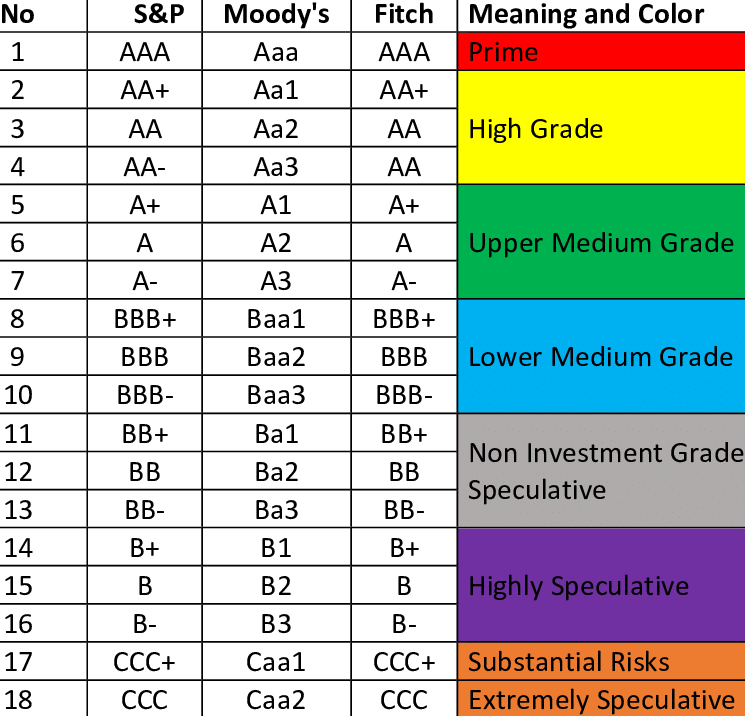

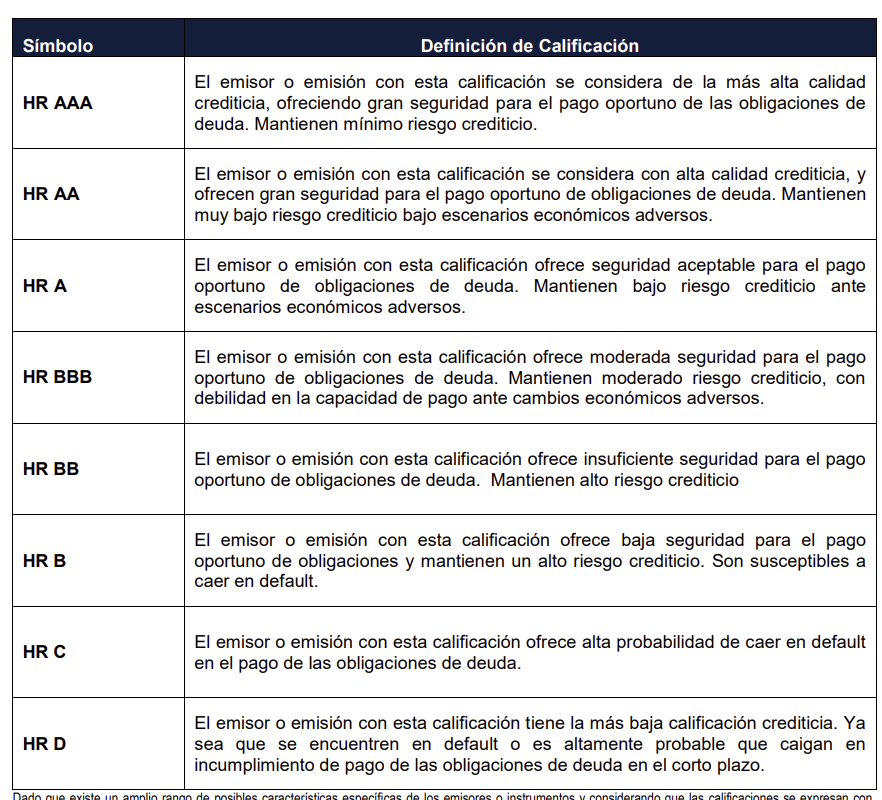

# Spread Curve

In [531]:
# The universe of bonds in final_bonds_data_df are the active bonds of mexican issuers in MXN currency.
# Now I will apply the next filters and calculate spread curve:
# Only straight bonds
# Fitch 'A', 'A-' or 'A+' rating or Moodys 'A3', 'A2' or 'A1' (I'm using this range because if I only filter by the same rating as AC the # of obs is not enough)
# No ESG bond
# years_to_maturity between 8 and 12
# Price available (liquid bond that has data of price)

first_spread_curve_df = final_bonds_data_df.copy()

first_spread_curve_df = first_spread_curve_df[first_spread_curve_df['Is Callable'] == 'N']
first_spread_curve_df = first_spread_curve_df[first_spread_curve_df['Is Straight'] == 'Y']
first_spread_curve_df = first_spread_curve_df[first_spread_curve_df['ESG Bond Flag'] == 'N']
first_spread_curve_df = first_spread_curve_df[first_spread_curve_df['years_to_maturity'].between(3, 7)]
first_spread_curve_df = first_spread_curve_df.dropna(subset=['Yield To Maturity'])

first_spread_curve_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity
71,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,105.88,MX91AC1J0048=VALR,6400000000.0,9.85,...,UN,Unsecured,8.599574,N,Y,N,<NA>,<NA>,2227.0,6.097194
87,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,UN,Unsecured,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255
175,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.02,LIVEPOL19=,5000000000.0,7.96,...,UN,Unsecured,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623
176,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.86,MX91LI050096=VALR,5000000000.0,8.03,...,UN,Unsecured,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745
248,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.24,LAMOSA19=,2000000000.0,9.12,...,UN,Unsecured,8.808894,N,Y,N,<NA>,C+,1367.0,3.742642
258,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,UN,Unsecured,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255
426,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.02,LIVEPOL19=,5000000000.0,7.96,...,UN,Unsecured,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623
427,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.86,MX91LI050096=VALR,5000000000.0,8.03,...,UN,Unsecured,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745
435,MX91HE010082,GRUPO HERDEZ SAB DE CV,Hechos con Amor SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,92.98,MX91HE010082=VALR,2500000000.0,7.78,...,UN,Unsecured,9.769249,N,Y,N,<NA>,A,1633.0,4.470910
450,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.24,LAMOSA19=,2000000000.0,9.12,...,UN,Unsecured,8.808894,N,Y,N,<NA>,C+,1367.0,3.742642


In [532]:
frequency_convertions = {'Semiannually': 182}

first_spread_curve_df["Coupon Frequency"] = (
    first_spread_curve_df["Coupon Frequency Description"]
    .map(frequency_convertions)
    .fillna(first_spread_curve_df["Coupon Frequency"]))

first_spread_curve_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity
71,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,105.88,MX91AC1J0048=VALR,6400000000.0,9.85,...,UN,Unsecured,8.599574,N,Y,N,<NA>,<NA>,2227.0,6.097194
87,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,UN,Unsecured,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255
175,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.02,LIVEPOL19=,5000000000.0,7.96,...,UN,Unsecured,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623
176,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.86,MX91LI050096=VALR,5000000000.0,8.03,...,UN,Unsecured,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745
248,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.24,LAMOSA19=,2000000000.0,9.12,...,UN,Unsecured,8.808894,N,Y,N,<NA>,C+,1367.0,3.742642
258,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,UN,Unsecured,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255
426,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.02,LIVEPOL19=,5000000000.0,7.96,...,UN,Unsecured,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623
427,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.86,MX91LI050096=VALR,5000000000.0,8.03,...,UN,Unsecured,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745
435,MX91HE010082,GRUPO HERDEZ SAB DE CV,Hechos con Amor SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,92.98,MX91HE010082=VALR,2500000000.0,7.78,...,UN,Unsecured,9.769249,N,Y,N,<NA>,A,1633.0,4.470910
450,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.24,LAMOSA19=,2000000000.0,9.12,...,UN,Unsecured,8.808894,N,Y,N,<NA>,C+,1367.0,3.742642


In [533]:
x = first_spread_curve_df["years_to_maturity"]

first_spread_curve_df["rf_interpolated_rate"] = np.where(
    (x >= 3) & (x < 5),
    calc_linear_interpolation(3, bond_mx_3_rate, 5, bond_mx_5_rate, x),
    np.where(
        (x >=  5) & (x < 10),
        calc_linear_interpolation(5, bond_mx_5_rate, 10, bond_mx_10_rate, x),
        np.where(
            (x >= 10) & (x <= 20),
            calc_linear_interpolation(10, bond_mx_10_rate, 20, bond_mx_20_rate, x),
            np.nan
        )
    ),
) * 100

first_spread_curve_df["ytm_calc"] = first_spread_curve_df.apply(
    lambda row: (
        pd.NA if row[["Price", "Coupon Rate", "Coupon Frequency",
                      "Issue Date", "Maturity Date"]].isna().any()
        else calc_ytm(
            row["Price"],
            row["Coupon Rate"],
            row["Coupon Frequency"],
            row["Issue Date"],
            row["Maturity Date"]
        )[0]
    ),
    axis=1
) * 100

# spread
first_spread_curve_df['spread'] = first_spread_curve_df['Yield To Maturity'] - first_spread_curve_df['rf_interpolated_rate']
first_spread_curve_df['spread_calc'] = first_spread_curve_df['ytm_calc'] - first_spread_curve_df['rf_interpolated_rate']

first_spread_curve_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity,rf_interpolated_rate,ytm_calc,spread,spread_calc
71,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,105.88,MX91AC1J0048=VALR,6400000000.0,9.85,...,Y,N,<NA>,<NA>,2227.0,6.097194,8.443387,9.613229,0.156187,1.169842
87,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,Y,N,<NA>,B-,1296.0,3.548255,8.265637,8.608707,0.175090,0.343071
175,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.02,LIVEPOL19=,5000000000.0,7.96,...,Y,N,<NA>,C+,1348.0,3.690623,8.274890,9.579446,1.096168,1.304556
176,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.86,MX91LI050096=VALR,5000000000.0,8.03,...,Y,N,<NA>,C+,1626.0,4.451745,8.324363,9.161210,0.644928,0.836846
248,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.24,LAMOSA19=,2000000000.0,9.12,...,Y,N,<NA>,C+,1367.0,3.742642,8.278272,8.992587,0.530622,0.714315
258,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,Y,N,<NA>,B-,1296.0,3.548255,8.265637,8.608707,0.175090,0.343071
426,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.02,LIVEPOL19=,5000000000.0,7.96,...,Y,N,<NA>,C+,1348.0,3.690623,8.274890,9.579446,1.096168,1.304556
427,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.86,MX91LI050096=VALR,5000000000.0,8.03,...,Y,N,<NA>,C+,1626.0,4.451745,8.324363,9.161210,0.644928,0.836846
435,MX91HE010082,GRUPO HERDEZ SAB DE CV,Hechos con Amor SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,92.98,MX91HE010082=VALR,2500000000.0,7.78,...,Y,N,<NA>,A,1633.0,4.470910,8.325609,9.997593,1.443640,1.671984
450,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.24,LAMOSA19=,2000000000.0,9.12,...,Y,N,<NA>,C+,1367.0,3.742642,8.278272,8.992587,0.530622,0.714315


In [534]:
first_spread_curve_df['Coupon Frequency Description'].value_counts()

Coupon Frequency Description
Every 182 days    11
Name: count, dtype: Int64

In [535]:
fitch_convertions = {'AAA(mex)': 'BBB+', 'AA(mex)': 'BBB' }

first_spread_curve_df["Issuer Fitch Long Rating"] = (
    first_spread_curve_df["Issuer Rating"]
    .map(fitch_convertions)
    .fillna(first_spread_curve_df["Issuer Fitch Long Rating"]))

first_spread_curve_df[['Issuer Rating', 'Rating Source Description', 'Issuer Name', 'Issuer Moodys Long Rating', 'Issuer Fitch Long Rating']]

,Issuer Rating,Rating Source Description,Issuer Name,Issuer Moodys Long Rating,Issuer Fitch Long Rating
71,A,Fitch Long-term Issuer Default Rating,AC BEBIDAS S DE RL DE CV,<NA>,A
87,AAA(mex),Fitch Long-term Issuer National Scale Rating,GMEXICO TRANSPORTES SAB DE CV,<NA>,BBB+
175,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
176,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
248,AA(mex),Fitch Long-term Issuer National Scale Rating,GRUPO LAMOSA SAB DE CV,<NA>,BBB
258,AAA(mex),Fitch Long-term Issuer National Scale Rating,GMEXICO TRANSPORTES SAB DE CV,<NA>,BBB+
426,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
427,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
435,AA(mex),Fitch Long-term Issuer National Scale Rating,GRUPO HERDEZ SAB DE CV,<NA>,BBB
450,AA(mex),Fitch Long-term Issuer National Scale Rating,GRUPO LAMOSA SAB DE CV,<NA>,BBB


In [ ]:
# curve spread

df_plot = first_spread_curve_df.sort_values('years_to_maturity')

fig, ax = plt.subplots()

ax.plot(
    df_plot['years_to_maturity'],
    df_plot['spread']
)

ax.set_xlabel('Years to Maturity')
ax.set_ylabel('Spread')
ax.set_title('Curve Spread')

plt.show()

In [ ]:
# curve spread

df_plot = first_spread_curve_df.sort_values('years_to_maturity')

fig, ax = plt.subplots()

ax.plot(
    df_plot['years_to_maturity'],
    df_plot['spread_calc']
)

ax.set_xlabel('Years to Maturity')
ax.set_ylabel('Spread')
ax.set_title('Curve Spread')

plt.show()

In [ ]:
first_spread_curve_by_credit_df = (first_spread_curve_df
                                      .groupby('Issuer Fitch Long Rating', as_index=False)['spread_calc']
                                      .mean()
                                      .rename(columns={'spread': 'mean_spread'}))

first_spread_curve_by_credit_df

In [539]:
import statsmodels.api as sm

df = first_spread_curve_df.sort_values("years_to_maturity").copy()

# make sure columns are numeric
df["years_to_maturity"] = pd.to_numeric(df["years_to_maturity"], errors="coerce")
df["spread"] = pd.to_numeric(df["spread_calc"], errors="coerce")
df = df.dropna(subset=["years_to_maturity", "spread"])

x = df["years_to_maturity"]
y = df["spread"]

# add constant (intercept term)
x_with_const = sm.add_constant(x)

# fit ols model: spread = a + b * maturity
model = sm.OLS(y, x_with_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 spread   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     2.015
Date:                Sun, 22 Feb 2026   Prob (F-statistic):              0.189
Time:                        22:55:56   Log-Likelihood:                -4.8863
No. Observations:                  11   AIC:                             13.77
Df Residuals:                       9   BIC:                             14.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.1280      0.72

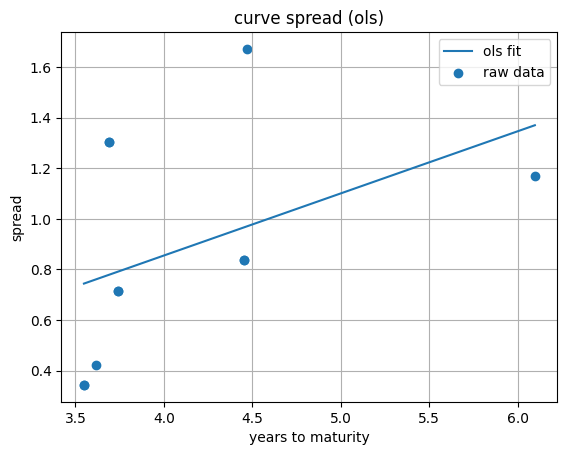

In [540]:
x_line = np.linspace(x.min(), x.max(), 200)
x_line_const = sm.add_constant(x_line)

y_line = model.predict(x_line_const)

fig, ax = plt.subplots()

ax.plot(x_line, y_line, label="ols fit")
ax.scatter(x, y, label="raw data")

ax.set_xlabel("years to maturity")
ax.set_ylabel("spread")
ax.set_title("curve spread (ols)")
ax.grid(True)
ax.legend()

plt.show()

In [543]:
x_new = pd.DataFrame({"years_to_maturity": [5.0]})
x_new = sm.add_constant(x_new, has_constant="add")  # force add intercept

predicted_spread = model.predict(x_new)
print(predicted_spread.iloc[0])

1.1005563371966738


In [494]:
print("slope:", b)
print("intercept:", a)

slope: 0.24570200788748167
intercept: -0.12795370224073357


In [471]:
# Credit spread

credit_spread_df = final_bonds_data_df.copy()

credit_spread_df = credit_spread_df[credit_spread_df['Is Callable'] == 'N']
credit_spread_df = credit_spread_df[credit_spread_df['Is Straight'] == 'Y']
credit_spread_df = credit_spread_df[credit_spread_df['ESG Bond Flag'] == 'N']
credit_spread_df = credit_spread_df[credit_spread_df['years_to_maturity'].between(3, 12)]
credit_spread_df = credit_spread_df.dropna(subset=['Yield To Maturity'])
credit_spread_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity
71,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,105.880,MX91AC1J0048=VALR,6400000000.0,9.85,...,UN,Unsecured,8.599574,N,Y,N,<NA>,<NA>,2227.0,6.097194
87,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.820,GMXT19=,6075000000.0,8.17,...,UN,Unsecured,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255
175,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.020,LIVEPOL19=,5000000000.0,7.96,...,UN,Unsecured,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623
176,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.860,MX91LI050096=VALR,5000000000.0,8.03,...,UN,Unsecured,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745
241,XS0300179602,GRUPO TELEVISA SAB,Grupo Televisa SAB,Consumer Cyclicals,Cyclical Consumer Services,Media & Publishing,70.919,MX030017960=,4500000000.0,8.49,...,SR,Senior Unsecured,13.610099,N,Y,N,<NA>,A-,4096.0,11.214237
248,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.240,LAMOSA19=,2000000000.0,9.12,...,UN,Unsecured,8.808894,N,Y,N,<NA>,C+,1367.0,3.742642
258,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.820,GMXT19=,6075000000.0,8.17,...,UN,Unsecured,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255
323,MX91TE000071,TELEFONOS DE MEXICO SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,94.740,TELMEX07=,5000000000.0,8.36,...,UN,Unsecured,9.639539,N,Y,N,<NA>,C,4040.0,11.060917
426,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.020,LIVEPOL19=,5000000000.0,7.96,...,UN,Unsecured,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623
427,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.860,MX91LI050096=VALR,5000000000.0,8.03,...,UN,Unsecured,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745


In [429]:
x = credit_spread_df["years_to_maturity"]

credit_spread_df["rf_interpolated_rate"] = np.where(
    (x >= 3) & (x < 5),
    calc_linear_interpolation(3, bond_mx_3_rate, 5, bond_mx_5_rate, x),
    np.where(
        (x >=  5) & (x < 10),
        calc_linear_interpolation(5, bond_mx_5_rate, 10, bond_mx_10_rate, x),
        np.where(
            (x >= 10) & (x <= 20),
            calc_linear_interpolation(10, bond_mx_10_rate, 20, bond_mx_20_rate, x),
            np.nan
        )
    ),
) * 100

# spread
credit_spread_df['spread'] = credit_spread_df['Yield To Maturity'] - credit_spread_df['rf_interpolated_rate']

credit_spread_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity,rf_interpolated_rate,spread
71,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,105.880,MX91AC1J0048=VALR,6400000000.0,9.85,...,8.599574,N,Y,N,<NA>,<NA>,2227.0,6.097194,8.443387,0.156187
87,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.820,GMXT19=,6075000000.0,8.17,...,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255,8.265637,0.175090
175,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.020,LIVEPOL19=,5000000000.0,7.96,...,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623,8.274890,1.096168
176,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.860,MX91LI050096=VALR,5000000000.0,8.03,...,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745,8.324363,0.644928
241,XS0300179602,GRUPO TELEVISA SAB,Grupo Televisa SAB,Consumer Cyclicals,Cyclical Consumer Services,Media & Publishing,70.919,MX030017960=,4500000000.0,8.49,...,13.610099,N,Y,N,<NA>,A-,4096.0,11.214237,8.806783,4.803316
248,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.240,LAMOSA19=,2000000000.0,9.12,...,8.808894,N,Y,N,<NA>,C+,1367.0,3.742642,8.278272,0.530622
258,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.820,GMXT19=,6075000000.0,8.17,...,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255,8.265637,0.175090
323,MX91TE000071,TELEFONOS DE MEXICO SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,94.740,TELMEX07=,5000000000.0,8.36,...,9.639539,N,Y,N,<NA>,C,4040.0,11.060917,8.798350,0.841189
426,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.020,LIVEPOL19=,5000000000.0,7.96,...,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623,8.274890,1.096168
427,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.860,MX91LI050096=VALR,5000000000.0,8.03,...,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745,8.324363,0.644928


In [430]:
credit_spread_df[['Issuer Rating', 'Rating Source Description', 'Issuer Name', 'Issuer Moodys Long Rating', 'Issuer Fitch Long Rating']]

,Issuer Rating,Rating Source Description,Issuer Name,Issuer Moodys Long Rating,Issuer Fitch Long Rating
71,A,Fitch Long-term Issuer Default Rating,AC BEBIDAS S DE RL DE CV,<NA>,A
87,AAA(mex),Fitch Long-term Issuer National Scale Rating,GMEXICO TRANSPORTES SAB DE CV,<NA>,<NA>
175,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
176,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
241,BB+,Fitch Long-term Issuer Default Rating,GRUPO TELEVISA SAB,WR,BB+
248,AA(mex),Fitch Long-term Issuer National Scale Rating,GRUPO LAMOSA SAB DE CV,<NA>,<NA>
258,AAA(mex),Fitch Long-term Issuer National Scale Rating,GMEXICO TRANSPORTES SAB DE CV,<NA>,<NA>
323,WR,Moody's Long-term Issuer National Scale Rating,TELEFONOS DE MEXICO SAB DE CV,WR,A-
426,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
427,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+


In [441]:
fitch_convertions = {'AAA(mex)': 'BBB+', 'AA(mex)': 'BBB' }

credit_spread_df["Issuer Fitch Long Rating"] = (
    credit_spread_df["Issuer Rating"]
    .map(fitch_convertions)
    .fillna(credit_spread_df["Issuer Fitch Long Rating"]))

credit_spread_df[['Issuer Rating', 'Rating Source Description', 'Issuer Name', 'Issuer Moodys Long Rating', 'Issuer Fitch Long Rating']]

,Issuer Rating,Rating Source Description,Issuer Name,Issuer Moodys Long Rating,Issuer Fitch Long Rating
71,A,Fitch Long-term Issuer Default Rating,AC BEBIDAS S DE RL DE CV,<NA>,A
87,AAA(mex),Fitch Long-term Issuer National Scale Rating,GMEXICO TRANSPORTES SAB DE CV,<NA>,BBB+
175,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
176,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
241,BB+,Fitch Long-term Issuer Default Rating,GRUPO TELEVISA SAB,WR,BB+
248,AA(mex),Fitch Long-term Issuer National Scale Rating,GRUPO LAMOSA SAB DE CV,<NA>,BBB
258,AAA(mex),Fitch Long-term Issuer National Scale Rating,GMEXICO TRANSPORTES SAB DE CV,<NA>,BBB+
323,WR,Moody's Long-term Issuer National Scale Rating,TELEFONOS DE MEXICO SAB DE CV,WR,A-
426,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+
427,BBB+,Fitch Long-term Issuer Default Rating,EL PUERTO DE LIVERPOOL SAB DE CV,<NA>,BBB+


In [438]:
fitch_credit_spread_df = (credit_spread_df
                          .groupby('Issuer Fitch Long Rating', as_index=False)['spread']
                          .median()
                          .rename(columns={'spread': 'mean_spread'}))

fitch_credit_spread_df

,Issuer Fitch Long Rating,mean_spread
0,A,0.156187
1,A-,0.841189
2,BB+,4.803316
3,BBB,0.175090
4,BBB+,0.870548
5,BBB-,0.530622


In [449]:
credit_spread_no_televisa_df = credit_spread_df[credit_spread_df["Issuer Name"] != "GRUPO TELEVISA SAB"]

fitch_credit_spread_no_televisa_df = (credit_spread_no_televisa_df
                                      .groupby('Issuer Fitch Long Rating', as_index=False)['spread']
                                      .mean()
                                      .rename(columns={'spread': 'mean_spread'}))

fitch_credit_spread_no_televisa_df

,Issuer Fitch Long Rating,mean_spread
0,A,0.156187
1,A-,0.841189
2,BBB,0.834961
3,BBB+,0.584409


In [ ]:
from sklearn.isotonic import IsotonicRegression

# Copy your dataframe
df = fitch_credit_spread_no_televisa_df.copy()
df['mean_spread'].iloc[0] = .78

# Define rating order (best -> worst)
rating_order = [
    "AAA","AA+","AA","AA-",
    "A+","A","A-",
    "BBB+","BBB","BBB-",
    "BB+","BB","BB-",
    "B+","B","B-",
    "CCC+","CCC","CCC-","CC","C","D"
]

# Create ranking dictionary
rank_map = {r: i for i, r in enumerate(rating_order)}

# Map ratings to numeric rank
df["rating_rank"] = df["Issuer Fitch Long Rating"].map(rank_map)

# Drop rows that didn't map
df = df.dropna(subset=["rating_rank"])

# Sort from best to worst
df = df.sort_values("rating_rank")

# Extract x (rank) and y (spread)
x = df["rating_rank"].values
y = df["mean_spread"].values

# Fit isotonic regression (monotonic increasing)
iso = IsotonicRegression(increasing=True)
df["smoothed_spread"] = iso.fit_transform(x, y)

df[["Issuer Fitch Long Rating", "mean_spread", "smoothed_spread"]]

C:\Users\Ramon\AppData\Local\Temp\ipykernel_11976\216375605.py:5:SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,Issuer Fitch Long Rating,mean_spread,smoothed_spread
0,A,0.780000,0.735199
1,A-,0.841189,0.735199
3,BBB+,0.584409,0.735199
2,BBB,0.834961,0.834961


[OMMSTREAMING_PRICING_0.0] on_ws_error: Exception: [WinError 10061] No connection could be made because the target machine actively refused it
[OMMSTREAMING_PRICING_0.0] on_ws_error: Exception: [WinError 10061] No connection could be made because the target machine actively refused it


In [328]:
credit_spread_no_televisa_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity,rf_interpolated_rate,spread
71,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,105.88,MX91AC1J0048=VALR,6400000000.0,9.85,...,8.599574,N,Y,N,<NA>,<NA>,2227.0,6.097194,8.443387,0.156187
87,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255,8.265637,0.175090
175,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.02,LIVEPOL19=,5000000000.0,7.96,...,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623,8.274890,1.096168
176,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.86,MX91LI050096=VALR,5000000000.0,8.03,...,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745,8.324363,0.644928
248,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.24,LAMOSA19=,2000000000.0,9.12,...,8.808894,N,Y,N,<NA>,C+,1367.0,3.742642,8.278272,0.530622
258,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255,8.265637,0.175090
323,MX91TE000071,TELEFONOS DE MEXICO SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,94.74,TELMEX07=,5000000000.0,8.36,...,9.639539,N,Y,N,<NA>,C,4040.0,11.060917,8.798350,0.841189
426,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.02,LIVEPOL19=,5000000000.0,7.96,...,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623,8.274890,1.096168
427,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.86,MX91LI050096=VALR,5000000000.0,8.03,...,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745,8.324363,0.644928
435,MX91HE010082,GRUPO HERDEZ SAB DE CV,Hechos con Amor SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,92.98,MX91HE010082=VALR,2500000000.0,7.78,...,9.769249,N,Y,N,<NA>,A,1633.0,4.470910,8.325609,1.443640


In [330]:
# maturity spread

maturity_spread_df = credit_spread_df.copy()

maturity_spread_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity,rf_interpolated_rate,spread
71,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,105.880,MX91AC1J0048=VALR,6400000000.0,9.85,...,8.599574,N,Y,N,<NA>,<NA>,2227.0,6.097194,8.443387,0.156187
87,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.820,GMXT19=,6075000000.0,8.17,...,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255,8.265637,0.175090
175,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.020,LIVEPOL19=,5000000000.0,7.96,...,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623,8.274890,1.096168
176,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.860,MX91LI050096=VALR,5000000000.0,8.03,...,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745,8.324363,0.644928
241,XS0300179602,GRUPO TELEVISA SAB,Grupo Televisa SAB,Consumer Cyclicals,Cyclical Consumer Services,Media & Publishing,70.919,MX030017960=,4500000000.0,8.49,...,13.610099,N,Y,N,<NA>,A-,4096.0,11.214237,8.806783,4.803316
248,MX91LA000016,GRUPO LAMOSA SAB DE CV,Grupo Lamosa SAB de CV,Consumer Cyclicals,Cyclical Consumer Products,Homebuilding & Construction Supplies,103.240,LAMOSA19=,2000000000.0,9.12,...,8.808894,N,Y,N,<NA>,C+,1367.0,3.742642,8.278272,0.530622
258,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.820,GMXT19=,6075000000.0,8.17,...,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255,8.265637,0.175090
323,MX91TE000071,TELEFONOS DE MEXICO SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,94.740,TELMEX07=,5000000000.0,8.36,...,9.639539,N,Y,N,<NA>,C,4040.0,11.060917,8.798350,0.841189
426,MX91LI050088,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,98.020,LIVEPOL19=,5000000000.0,7.96,...,9.371058,N,Y,N,<NA>,C+,1348.0,3.690623,8.274890,1.096168
427,MX91LI050096,EL PUERTO DE LIVERPOOL SAB DE CV,El Puerto de Liverpool SAB de CV,Consumer Cyclicals,Retailers,Diversified Retail,96.860,MX91LI050096=VALR,5000000000.0,8.03,...,8.969291,N,Y,N,<NA>,C+,1626.0,4.451745,8.324363,0.644928


In [ ]:
maturity_spread_by_m = (credit_spread_no_televisa_df
                        .groupby('Issuer Fitch Long Rating', as_index=False)
                                      .mean()
                                      .rename(columns={'spread': 'mean_spread'}))

In [455]:
# The universe of bonds in final_bonds_data_df are the active bonds of mexican issuers in MXN currency.
# Now I will apply the next filters and calculate spread curve:
# Only straight bonds
# Fitch 'A', 'A-' or 'A+' rating or Moodys 'A3', 'A2' or 'A1' (I'm using this range because if I only filter by the same rating as AC the # of obs is not enough)
# No ESG bond
# years_to_maturity between 8 and 12
# Price available (liquid bond that has data of price)

second_spread_curve_df = final_bonds_data_df.copy()

second_spread_curve_df = second_spread_curve_df[second_spread_curve_df['Is Callable'] == 'N']
second_spread_curve_df = second_spread_curve_df[second_spread_curve_df['ESG Bond Flag'] == 'N']
second_spread_curve_df = second_spread_curve_df[second_spread_curve_df['years_to_maturity'].between(3, 7)]

second_spread_curve_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity
1,MX91VA2600J3,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600J3=VALR,1000000000.0,9.68,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1143.0,3.129363
2,MX91VA2600K1,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600K1=VALR,500000000.0,9.75,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1208.0,3.307324
3,MX91VA2600L9,VALUE ARRENDADORA SA DE CV SOFOM ER VALUE GRUP...,Value Grupo Financiero SAB de CV,Financials,Banking & Investment Services,Banking Services,NaN,MX91VA2600L9=VALR,500000000.0,9.75,...,UN,Unsecured,NaN,N,N,N,<NA>,<NA>,1325.0,3.627652
55,MX91TR0H0015,GRUPO TRAXION SAB DE CV,Grupo Traxion SAB de CV,Industrials,Transportation,Freight & Logistics Services,NaN,TRAXION26=VALR,1000000000.0,13.0,...,UN,Unsecured,NaN,N,N,N,<NA>,A-,2181.0,5.971253
56,MX91TR0H0023,GRUPO TRAXION SAB DE CV,Grupo Traxion SAB de CV,Industrials,Transportation,Freight & Logistics Services,NaN,TRAXION262=VALR,1000000000.0,13.0,...,UN,Unsecured,NaN,N,N,N,<NA>,A-,2545.0,6.967830
71,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,105.88,MX91AC1J0048=VALR,6400000000.0,9.85,...,UN,Unsecured,8.599574,N,Y,N,<NA>,<NA>,2227.0,6.097194
72,MX91AC1J0071,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,NaN,MX91AC1J0071=VALR,6240000000.0,8.96,...,UN,Unsecured,NaN,N,Y,N,<NA>,<NA>,2530.0,6.926762
82,MX91BI0Y00E2,GRUPO BIMBO SAB DE CV,Grupo Bimbo SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,NaN,MX91BI0Y00E2=VALR,4133375000.0,7.45,...,UN,Unsecured,NaN,N,N,N,<NA>,A,1440.0,3.942505
87,MX91GM1Z0028,GMEXICO TRANSPORTES SAB DE CV,Grupo Mexico SAB de CV,Industrials,Transportation,Freight & Logistics Services,102.82,GMXT19=,6075000000.0,8.17,...,UN,Unsecured,8.440727,N,Y,N,<NA>,B-,1296.0,3.548255
167,MX91GA0000J9,GRUPO AEROPORTUARIO DEL PACIFICO SAB DE CV,Grupo Aeroportuario del Pacifico SAB de CV,Industrials,Transportation,Transport Infrastructure,102.99,MX91GA0000J9=VALR,5648134300.0,7.88,...,UN,Unsecured,7.555700,N,N,N,<NA>,B,1285.0,3.518138


[OMMSTREAMING_PRICING_0.0] on_ws_error: Exception: [WinError 10061] No connection could be made because the target machine actively refused it


In [512]:
esg_bonds_df = final_bonds_data_df.copy()

esg_bonds_df = esg_bonds_df[esg_bonds_df['ESG Bond Flag'] == 'Y']
esg_bonds_df = esg_bonds_df[esg_bonds_df['years_to_maturity'].between(2, 8)]
esg_bonds_df = esg_bonds_df[esg_bonds_df['Issuer Fitch Long Rating'].isin(['A', 'A-', 'BBB+', 'BBB', 'BBB-'])]

esg_bonds_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Price,RIC,Amount Outstanding,Coupon Rate,...,Seniority Type,Seniority Type Description,Yield To Maturity,Is Callable,Is Straight,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity
69,MX91AC1J0030,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100.1800,ACBE212V=,3000000000.0,6.75,...,UN,Unsecured,7.701191,N,Y,Y,Self-Labeled Green Bond,<NA>,800.0,2.190281
84,MX91BI0Y00B8,GRUPO BIMBO SAB DE CV,Grupo Bimbo SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100.0100,MX91BI0Y00B8=VALR,12000000000.0,9.24,...,UN,Unsecured,9.233808,Y,N,Y,Sustainability Linked Bond,A,2644.0,7.238877
156,MX91OR010021,ORBIA ADVANCE CORPORATION SAB DE CV,Orbia Advance Corporation SAB de CV,Basic Materials,Chemicals,Chemicals,NaN,MX91OR010021=VALR,15560000000.0,10.63,...,UN,Unsecured,NaN,N,Y,Y,Sustainability Linked Bond,A,2468.0,6.757016
317,XS2645737003,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,103.3726,MX264573700=,23000000000.0,9.5,...,SR,Senior Unsecured,8.641475,Y,N,Y,Sustainability Bond,B,1800.0,4.928131
318,MX91AM0500P3,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100.0100,MX91AM0500P3=VALR,14679165700.0,9.52,...,UN,Unsecured,9.512164,Y,N,Y,Sustainability Bond,B,2458.0,6.729637
319,XS2701559440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,106.7300,MX270155944=,23500000000.0,10.3,...,SR,Senior Unsecured,9.083780,Y,N,Y,Sustainability Bond,B,2899.0,7.937029
370,MX91BI0Y00B8,GRUPO BIMBO SAB DE CV,Grupo Bimbo SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100.0100,MX91BI0Y00B8=VALR,12000000000.0,9.24,...,UN,Unsecured,9.233808,Y,N,Y,Sustainability Linked Bond,A,2644.0,7.238877
407,MX91OR010021,ORBIA ADVANCE CORPORATION SAB DE CV,Orbia Advance Corporation SAB de CV,Basic Materials,Chemicals,Chemicals,NaN,MX91OR010021=VALR,15560000000.0,10.63,...,UN,Unsecured,NaN,N,Y,Y,Sustainability Linked Bond,A,2468.0,6.757016
519,XS2645737003,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,103.3726,MX264573700=,23000000000.0,9.5,...,SR,Senior Unsecured,8.641475,Y,N,Y,Sustainability Bond,B,1800.0,4.928131
520,MX91AM0500P3,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100.0100,MX91AM0500P3=VALR,14679165700.0,9.52,...,UN,Unsecured,9.512164,Y,N,Y,Sustainability Bond,B,2458.0,6.729637


In [515]:
esg_bonds_df.to_excel('esg_bonds_data.xlsx')